1.Генерируем файл csv.
* Задаем константы
* При помощи linespase генерируем значения
* Записываем наши значения в таблицу

In [ ]:
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt

In [ ]:
num = 500
start_point = -100
end_point = 100

In [ ]:
x1 = np.linspace(start_point, end_point, num)
x2 = np.linspace(start_point, end_point, num)
y = np.sin(x1 + x2)

In [ ]:
data_frame = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

In [ ]:
data_frame.to_csv('data.csv', index=False)

2.Импортируем нашу таблицу и построим график

In [ ]:
data = pd.read_csv('data.csv')

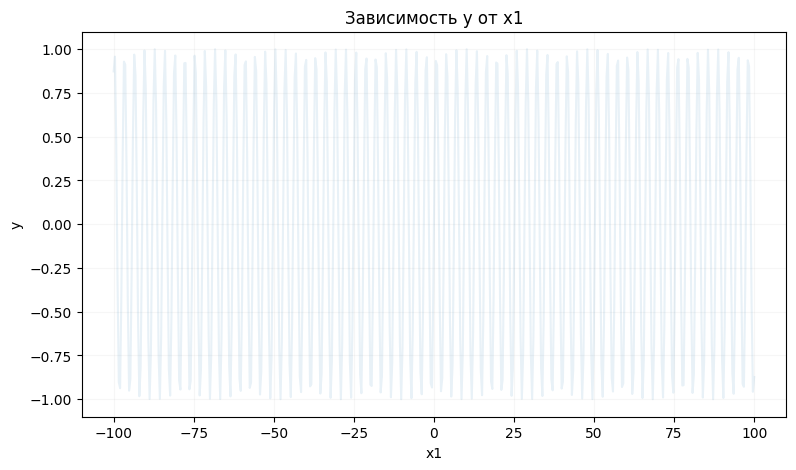

In [ ]:
plt.figure(figsize=(20, 5))
x2_const = data['x2'].mean()

plt.subplot(1, 2, 1)
plt.plot(data['x1'], data['y'], alpha=0.1, label='Все точки')
plt.xlabel('x1')
plt.ylabel('y')
plt.title(f'Зависимость y от x1')
plt.grid(True, alpha=0.1)

Text(0.5, 1.0, 'Зависимость y от x2')

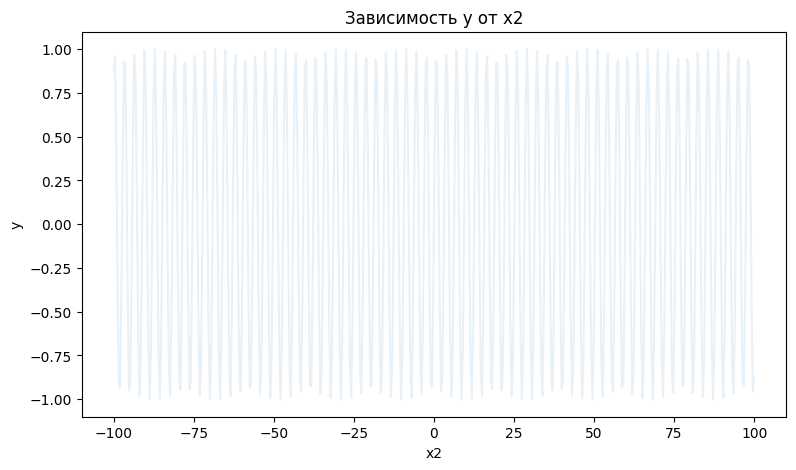

In [ ]:
plt.figure(figsize=(20, 5))
x1_const = data['x1'].mean()

plt.subplot(1, 2, 2)
plt.plot(data['x2'], data['y'], alpha=0.1, label='Все точки')
plt.xlabel('x2')
plt.ylabel('y')
plt.title(f'Зависимость y от x2')

3.Выведем для каждого столбца среднее, миимальное и максимальное значение

In [ ]:
stats_data = pd.DataFrame({
    'Среднее': data.mean(),
    'Минимум': data.min(),
    'Максимум': data.max(),
})
print(stats_data)

         Среднее     Минимум    Максимум
x1  3.637979e-15 -100.000000  100.000000
x2  3.637979e-15 -100.000000  100.000000
y  -3.508305e-16   -0.999995    0.999995


4.Сохраним в новый CSV файл те строки, для которых выполняется условие: x1 < mean(x1) или x2 < mean(x2)

In [ ]:
condition_data = pd.DataFrame(data[(data['x1'] < data['x1'].mean()) | (data['x2'] < data['x2'].mean())])
condition_data.to_csv('condition_data.csv', index=False)

In [ ]:
condition_data.tail(10)

,x1,x2,y
240,-3.807615,-3.807615,-0.971634
241,-3.406814,-3.406814,-0.505915
242,-3.006012,-3.006012,0.267850
243,-2.605210,-2.605210,0.878524
244,-2.204409,-2.204409,0.954275
245,-1.803607,-1.803607,0.448978
246,-1.402806,-1.402806,-0.329696
247,-1.002004,-1.002004,-0.907622
248,-0.601202,-0.601202,-0.932908
249,-0.200401,-0.200401,-0.390157


5.Построим 3д График функции y = sin(x1 + x2) при помощи mplot3d

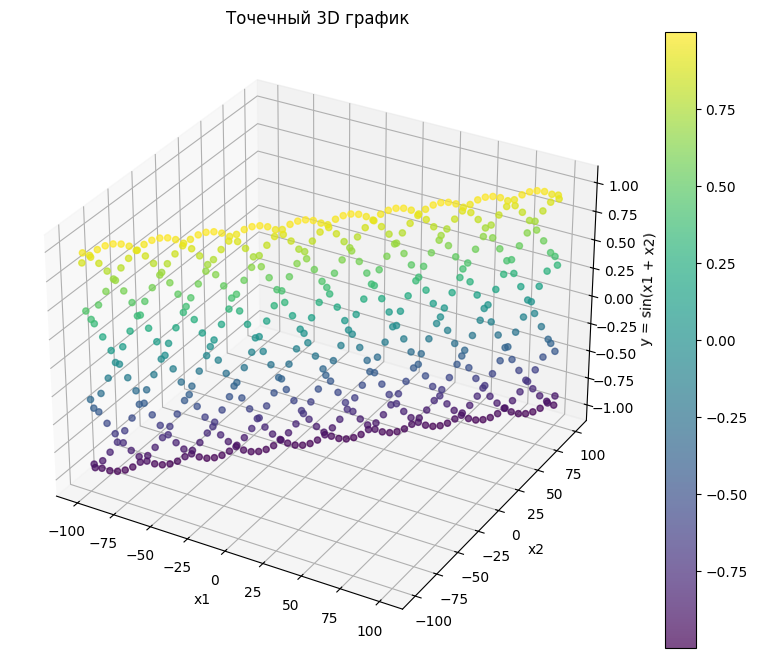

In [ ]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Точечный график
scatter = ax.scatter(data['x1'], data['x2'], data['y'],
                    c=data['y'],
                    cmap='viridis',
                    s=20,  # размер точек
                    alpha=0.7)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y = sin(x1 + x2)')
ax.set_title('Точечный 3D график')

plt.colorbar(scatter, ax=ax)
plt.show()